# Laboratory Partial

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

import warnings

warnings.filterwarnings("ignore")

# Exercise 1 (1 point)

A scientist studies how a chemical reaction rate depends on temperature. The Arrhenius equation gives the rate constant $k$ as:

$$k = A\, e^{-\frac{E_a}{RT}}$$

where $A$ is the pre-exponential factor, $E_a$ the activation energy, and $R = 8.3145$ J/(mol·K) the universal gas constant.

Experimental data:

$$\{(k, T)\} = \{(0.0021, 300\,\text{K}),\,(0.0063, 320\,\text{K}),\,(0.0192, 340\,\text{K}),\,(0.0580, 360\,\text{K}),\,(0.1650, 380\,\text{K})\}$$

Estimate $A$ and $E_a$ using:

- Direct pseudoinverse (0.5 points)
- Pseudoinverse via SVD (0.5 points)

In [2]:
R = 8.3145

k = np.array([0.0021, 0.0063, 0.0192, 0.0580, 0.1650])
T = np.array([300, 320, 340, 360, 380])

y = np.log(k)
X = np.column_stack([np.ones(len(T)), 1.0 / T])

In [15]:
# Direct pseudoinverse
theta = np.linalg.pinv(X) @ y
lnA_ps, m_ps = theta

A_est_ps = np.exp(lnA_ps)
Ea_est_ps = -m_ps * R

print(f"A (Pseudoinversa) = {A_est_ps:.6f}")
print(f"Ea (Pseudoinversa) = {Ea_est_ps:.2f} J/mol")

A (Pseudoinversa) = 1933079.134407
Ea (Pseudoinversa) = 51770.63 J/mol


In [14]:
# Pseudoinverse via SVD
def solve_lm_svd(X, t):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    Sigma_inv = np.diag(1 / s)
    beta_svd = Vt.T @ Sigma_inv @ U.T @ t
    return beta_svd

lnA_svd, m_svd = solve_lm_svd(X, y)

A_est_svd = np.exp(lnA_svd)
Ea_est_svd = -m_svd * R

print(f"A (SVD) = {A_est_svd:.6f}")
print(f"Ea (SVD) = {Ea_est_svd:.2f} J/mol")

A (SVD) = 1933079.134407
Ea (SVD) = 51770.63 J/mol


# Exercise 2 (2.5 points)

You are studying two species of mice: **Field Mice** and **House Mice**, characterised by:

- **Ear Size** (mm)
- **Tail Length** (cm)

Training data:

| Mouse | Ear Size (mm) | Tail Length (cm) | Species     |
|------:|--------------:|-----------------:|:------------|
|     1 |            25 |             10.0 | Field Mouse |
|     3 |            24 |              9.5 | Field Mouse |
|     4 |            12 |              5.0 | House Mouse |
|     6 |            11 |              4.5 | House Mouse |

Validation data:

| Mouse | Ear Size (mm) | Tail Length (cm) | Species     |
|------:|--------------:|-----------------:|:------------|
|     5 |            13 |              6.0 | House Mouse |
|     2 |            27 |             11.0 | Field Mouse |

In [16]:
# [Ear Size, Tail Length, Bias]
X_train = np.array([[25, 10.0, 1], [24, 9.5, 1], [12, 5.0, 1], [11, 4.5, 1]])
y_train = np.array([1, 1, -1, -1])  # Field=+1, House=-1

X_val = np.array([[13, 6.0, 1], [27, 11.0, 1]])
y_val = np.array([-1, 1])

1. Plot the training and validation data. (0.25 points)

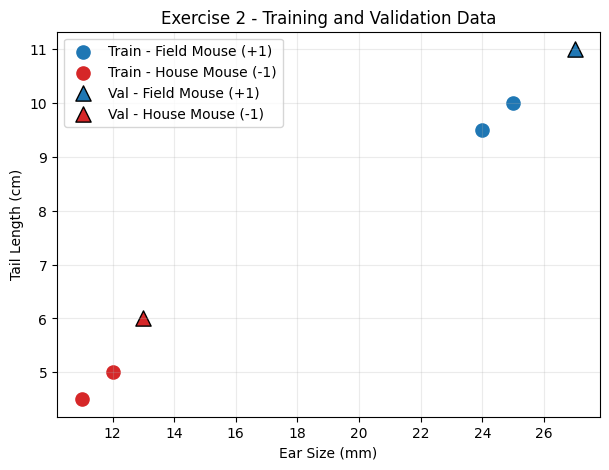

In [21]:
# Plot training and validation data
plt.figure(figsize=(7, 5))

# Training
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='tab:blue', marker='o', s=90, label='Train - Field Mouse (+1)')
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1],
            c='tab:red', marker='o', s=90, label='Train - House Mouse (-1)')

# Validation
plt.scatter(X_val[y_val == 1, 0], X_val[y_val == 1, 1],
            c='tab:blue', marker='^', s=120, edgecolors='k', label='Val - Field Mouse (+1)')
plt.scatter(X_val[y_val == -1, 0], X_val[y_val == -1, 1],
            c='tab:red', marker='^', s=120, edgecolors='k', label='Val - House Mouse (-1)')

plt.xlabel('Ear Size (mm)')
plt.ylabel('Tail Length (cm)')
plt.title('Exercise 2 - Training and Validation Data')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

2. Complete the vectorised Perceptron Learning rule below. *Vectorised* means no inner loops over samples. (1 point)

In [30]:
w = np.zeros(3)
mistake = True
iters = 0

while mistake:
    mistake = False
    scores = X_train @ w
    misclassified = (y_train * scores) <= 0

    if np.any(misclassified):
        w += np.sum((y_train[misclassified, None] * X_train[misclassified]), axis=0)
        mistake = True
        iters += 1

print("w =", w)
print("iteracions =", iters)

w = [  9.  -15.5 -58. ]
iteracions = 80


In [23]:
y_val_pred = np.sign(X_val @ w)

pd.DataFrame({
    "Mouse": [5, 2],
    "Predicted": np.where(y_val_pred == 1, "Field Mouse", "House Mouse"),
    "True":      ["House Mouse", "Field Mouse"]
})

,Mouse,Predicted,True
0,5,House Mouse,House Mouse
1,2,Field Mouse,Field Mouse


3. Is the vectorised Perceptron appropriate for this problem? (0.25 points)

*Your answer.*

4. Compute the margin $\gamma$ of your classifier. Check that the number of mistakes satisfies the convergence theorem bound. (0.5 points)

In [28]:
# Fem servir el classificador obtingut al punt 2 (vector w)
norm_w = np.linalg.norm(w)
signed = y_train * (X_train @ w)
gamma = np.min(signed) / norm_w if norm_w > 0 else 0.0

# Radi màxim dels punts
R = np.max(np.linalg.norm(X_train, axis=1))

# Comptem errors del Perceptró "clàssic" (1 mostra cada cop), que és el del teorema
w_th = np.zeros(3)
T = 0  # nombre d'errors (updates)
max_epochs = 1000

for _ in range(max_epochs):
    changed = False
    for xi, yi in zip(X_train, y_train):
        if yi * (w_th @ xi) <= 0:
            w_th = w_th + yi * xi
            T += 1
            changed = True
    if not changed:
        break

bound = (R / gamma) ** 2 if gamma > 0 else np.inf

print(f"w (punt 2) = {w}")
print(f"gamma = {gamma:.6f}")
print(f"R = {R:.6f}")
print(f"T (errors perceptró clàssic) = {T}")
print(f"Bound (R/gamma)^2 = {bound:.6f}")
print("Es compleix T <= (R/gamma)^2 ?", T <= bound)

w (punt 2) = [  9.  -15.5 -58. ]
gamma = 0.177082
R = 26.944387
T (errors perceptró clàssic) = 104
Bound (R/gamma)^2 = 23151.900487
Es compleix T <= (R/gamma)^2 ? True


5. Normalise the data and re-run. Does convergence change? Why? (0.5 points)

In [31]:
# Normalitza amb estadístiques del train (només features, no el biaix)
mu = X_train[:, :2].mean(axis=0)
sigma = X_train[:, :2].std(axis=0)

X_train_n = X_train.copy().astype(float)
X_val_n = X_val.copy().astype(float)

X_train_n[:, :2] = (X_train_n[:, :2] - mu) / sigma
X_val_n[:, :2] = (X_val_n[:, :2] - mu) / sigma
X_train_n[:, 2] = 1.0
X_val_n[:, 2] = 1.0

# Re-run perceptró vectoritzat
w_n = np.zeros(3)
mistake = True
iters = 0

while mistake:
    mistake = False
    scores = X_train_n @ w_n
    misclassified = (y_train * scores) <= 0

    if np.any(misclassified):
        w_n += np.sum(y_train[misclassified, None] * X_train_n[misclassified], axis=0)
        mistake = True
        iters += 1

print("w normalitzat =", w_n)
print("iteracions =", iters)

y_val_pred_n = np.sign(X_val_n @ w_n)
print("prediccions val =", y_val_pred_n)
print("accuracy val =", np.mean(y_val_pred_n == y_val))

w normalitzat = [3.98821794 3.98014876 0.        ]
iteracions = 1
prediccions val = [-1.  1.]
accuracy val = 1.0


*Your answer.*

# Exercise 3 (2.5 points)

A weather station records the number of strong wind gusts (above 50 km/h) per day. You want to predict tomorrow's gust count based on today's observations:

- `Today_Wind`: mean wind speed today (km/h)
- `Today_Temp_Effect`: temperature-driven wind contribution today (km/h)
- `Local_Pressure`: local pressure-driven wind contribution (km/h)
- `Prev_Day_Wind`: mean wind speed yesterday (km/h)

In [32]:
train_data = pd.DataFrame({
    'Today_Wind':        [12.331344, 14.190451, 11.061576, 14.765765, 14.465941,
                           9.693871, 12.531540, 13.949093, 12.392729, 11.970554,
                          13.940820, 12.685564, 13.464540, 12.294099, 11.141531,
                          14.712357, 11.082903, 10.657860, 12.078670, 15.183309],
    'Today_Temp_Effect': [26.44320, 25.76959, 22.69044, 21.47019, 21.09764,
                          19.52647, 21.96041, 16.67302, 33.84478, 29.03981,
                          17.38446, 20.98558, 20.66672, 26.89983, 22.58315,
                          24.26659, 22.85727, 22.78565, 29.84301, 21.87115],
    'Local_Pressure':    [19.549412, 10.353742, 16.753841, 15.371563, 15.647825,
                          16.138918, 13.493030, 14.000378, 11.944274, 11.784626,
                          15.910586, 16.344629, 15.159013, 17.766802, 21.150254,
                          13.526907,  8.072493, 18.017216, 12.872398, 12.935974],
    'Prev_Day_Wind':     [11.95067, 13.79914, 11.43453, 14.50574, 14.63289,
                          10.23066, 12.83317, 14.27677, 13.07936, 12.17283,
                          14.95006, 12.81509, 13.60544, 12.70020, 11.08903,
                          14.99588, 11.50464, 10.32966, 11.32565, 15.45284],
    'Gusts_Tomorrow':    [27, 18, 24, 27, 20, 21, 20, 18, 21, 19,
                          21, 19, 23, 29, 21, 24, 19, 23, 20, 22]
})

valid_data = pd.DataFrame({
    'Today_Wind':        [14.14757, 14.55768, 13.96884, 14.85350, 12.76532,
                          13.18745, 12.84877, 12.84736, 11.27203, 10.25976],
    'Today_Temp_Effect': [22.77486, 19.07548, 14.66029, 21.09887, 27.59498,
                          20.12327, 26.03982, 14.91059, 22.72219, 25.59704],
    'Local_Pressure':    [15.90346, 15.31703, 13.07788, 12.45089, 11.92761,
                          15.35294, 12.15758, 13.52833, 14.23172, 20.53159],
    'Prev_Day_Wind':     [10.535997, 14.876336, 13.670299,  9.200209, 12.850680,
                          22.209957, 15.429354, 13.218108,  8.910818, -1.583915],
    'Gusts_Tomorrow':    [23, 23, 18, 23, 21, 24, 19, 16, 27, 24]
})

print(train_data.head())
print(valid_data.head())

   Today_Wind  Today_Temp_Effect  Local_Pressure  Prev_Day_Wind  \
0   12.331344           26.44320       19.549412       11.95067   
1   14.190451           25.76959       10.353742       13.79914   
2   11.061576           22.69044       16.753841       11.43453   
3   14.765765           21.47019       15.371563       14.50574   
4   14.465941           21.09764       15.647825       14.63289   

   Gusts_Tomorrow  
0              27  
1              18  
2              24  
3              27  
4              20  
   Today_Wind  Today_Temp_Effect  Local_Pressure  Prev_Day_Wind  \
0    14.14757           22.77486        15.90346      10.535997   
1    14.55768           19.07548        15.31703      14.876336   
2    13.96884           14.66029        13.07788      13.670299   
3    14.85350           21.09887        12.45089       9.200209   
4    12.76532           27.59498        11.92761      12.850680   

   Gusts_Tomorrow  
0              23  
1              23  
2             

1. Fit a suitable model to predict `Gusts_Tomorrow`. Report training and validation errors.
2. How can you improve generalisation? Choose and justify the best hyperparameters.

In [34]:
# 3.1 Fit model + errors (train i validation)
features = ["Today_Wind", "Today_Temp_Effect", "Local_Pressure", "Prev_Day_Wind"]
target = "Gusts_Tomorrow"

X_tr = train_data[features].values
y_tr = train_data[target].values

X_va = valid_data[features].values
y_va = valid_data[target].values

model = LinearRegression()
model.fit(X_tr, y_tr)

y_tr_pred = model.predict(X_tr)
y_va_pred = model.predict(X_va)

mse_tr = np.mean((y_tr - y_tr_pred) ** 2)
mse_va = np.mean((y_va - y_va_pred) ** 2)

rmse_tr = np.sqrt(mse_tr)
rmse_va = np.sqrt(mse_va)

mae_tr = np.mean(np.abs(y_tr - y_tr_pred))
mae_va = np.mean(np.abs(y_va - y_va_pred))

print("Model: Linear Regression")
print(f"Train   -> MSE: {mse_tr:.4f}, RMSE: {rmse_tr:.4f}, MAE: {mae_tr:.4f}")
print(f"Valid   -> MSE: {mse_va:.4f}, RMSE: {rmse_va:.4f}, MAE: {mae_va:.4f}")

Model: Linear Regression
Train   -> MSE: 5.4335, RMSE: 2.3310, MAE: 2.0097
Valid   -> MSE: 20.7829, RMSE: 4.5588, MAE: 3.6396


In [36]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
results = []

for model_name, model_cls in [("Ridge", Ridge), ("Lasso", Lasso)]:
    for a in alphas:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model_cls(alpha=a, max_iter=10000))
        ])

        pipe.fit(X_tr, y_tr)

        y_tr_pred = pipe.predict(X_tr)
        y_va_pred = pipe.predict(X_va)

        mse_tr = np.mean((y_tr - y_tr_pred) ** 2)
        mse_va = np.mean((y_va - y_va_pred) ** 2)

        rmse_tr = np.sqrt(mse_tr)
        rmse_va = np.sqrt(mse_va)

        mae_tr = np.mean(np.abs(y_tr - y_tr_pred))
        mae_va = np.mean(np.abs(y_va - y_va_pred))

        results.append({
            "model": model_name,
            "alpha": a,
            "rmse_train": rmse_tr,
            "rmse_val": rmse_va,
            "mae_train": mae_tr,
            "mae_val": mae_va
        })

res_df = pd.DataFrame(results).sort_values("rmse_val").reset_index(drop=True)
print(res_df.head(10))

best = res_df.iloc[0]
print("\nBest model:")
print(best)

   model    alpha  rmse_train  rmse_val  mae_train   mae_val
0  Ridge   10.000    2.478862  2.834004   2.030617  2.278967
1  Lasso    1.000    2.763147  2.947410   2.259749  2.380743
2  Ridge  100.000    2.881303  3.021461   2.362501  2.533897
3  Lasso   10.000    3.026549  3.124100   2.460000  2.640000
4  Lasso  100.000    3.026549  3.124100   2.460000  2.640000
5  Ridge    1.000    2.338220  3.283311   2.007055  2.540803
6  Lasso    0.100    2.344752  3.406845   1.990695  2.707015
7  Lasso    0.010    2.332133  3.794763   2.007290  3.005534
8  Ridge    0.100    2.331209  4.245479   2.009018  3.390376
9  Lasso    0.001    2.331014  4.460390   2.009469  3.561509

Best model:
model            Ridge
alpha             10.0
rmse_train    2.478862
rmse_val      2.834004
mae_train     2.030617
mae_val       2.278967
Name: 0, dtype: object


*Your answer.*

# Exercise 4 (4 points)

Predict whether a patient will experience disorientation within 12 hours of receiving a 100 mg dose of a new medication.

Predictors: body fat, meat in diet, stress level, blood oxygen, blood sugar.

In [37]:
train_data = pd.DataFrame({
    'fat':   [15.22442, 28.51168,  6.13891, 18.20264, 16.41537, 19.31584,  7.57312, 27.49562,  6.05149, 13.19802, 28.86259, 21.01267, 21.39264, 19.85355, 12.22899, 29.07561, 27.55748, 24.88669, 16.94490, 23.96149, 12.95453, 10.79064, 15.34311,  8.81112,  8.47015, 10.82585, 16.64906,  6.14578, 10.16328,  7.37102, 15.99579, 23.86188,  5.01562, 10.50297, 14.49541, 13.79495,  7.77839, 11.09049,  7.57162,  9.37632,  8.26739, 13.00933,  7.33987, 16.66948, 19.99972, 17.21533, 28.86185, 17.07256,  8.67737, 28.38250,  8.55736, 18.73212, 12.69300, 14.23722,  8.85506,  7.27610, 20.48141, 21.82498, 23.42694, 24.65704, 15.23687, 26.06823, 11.14309, 11.16122,  7.77741, 14.74986, 21.24963, 18.34220, 10.52757, 15.31865, 11.64217, 23.66420, 21.70712, 12.81120, 22.70726, 17.03225, 11.62582, 27.54686, 13.03707, 29.64102,  8.80867, 19.32168, 10.96815, 20.03414, 12.20598,  9.26613,  9.30429, 17.05107, 22.52133, 23.20986, 27.89209, 15.71054,  6.46196, 20.82638, 24.63229, 15.10998, 16.78941, 28.14270, 17.57033,  5.15752,  9.10528, 21.22045, 23.96483,  6.62321,  6.36573, 12.44354, 27.01101, 25.41515, 29.55351,  7.58999, 24.97079, 24.61438,  5.23575, 23.23477, 20.75330,  5.20539, 17.30733],
    'meat':  [121.7750, 141.3636,  94.5035, 184.0134, 135.3303, 148.9152, 233.9748,  92.9359, 242.5512,  65.6625, 253.7704, 128.0282, 179.7012,  56.3817, 297.2696, 284.7846, 221.9019, 254.1195, 234.7579, 137.1799, 183.8853, 118.6363, 258.0269, 238.2775, 291.0381,  70.3666, 263.5912, 131.8993, 196.7397, 282.3377, 271.2832, 188.3285, 155.8659, 227.2595, 153.3264, 191.6835, 172.5159, 269.6685, 268.4875, 195.6849, 181.6475,  72.0908, 134.3738, 273.5837, 109.3074, 106.4546, 129.6236,  93.4960, 143.5423, 207.4364, 245.4558, 272.9740, 243.8519,  60.5270, 118.4378, 262.6169, 239.7838, 164.4804, 232.4079, 238.0094, 249.7059,  72.5805, 125.1294, 191.7799, 234.1551, 264.3619,  79.3328,  68.7392,  89.2920, 211.7643,  93.3794, 120.7506, 155.1087, 228.6887, 257.8055, 187.6542, 180.5839, 113.4552, 208.7001, 184.8902, 157.1533, 138.9404, 261.2334,  55.7861, 144.1111,  96.4683, 157.2351, 207.6934, 146.1142, 235.6348,  55.7137, 268.7206, 281.1197, 199.3384, 172.4593, 272.0929,  59.1761, 178.4453, 213.3570, 253.2783, 251.8748, 252.1530, 114.7003, 100.8543, 120.7832, 283.4241, 172.3570, 151.9077,  75.9279, 120.1413, 114.8112, 167.6705, 141.4614,  61.7484, 115.6991, 169.4555, 216.9101],
    'stress':[16.01848, 84.77392, 47.78868, 77.36921, 44.05331, 50.69977,  1.91910, 77.36860, 64.14626, 46.84321, 27.92238, 58.55656, 81.12373, 45.54890, 26.88034, 23.12309, 54.32329, 13.02881, 54.79943, 14.92442, 42.68856, 44.77301, 45.68868, 24.24571,  7.58608, 39.12951,  1.31082, 70.88554, 27.64399, 17.30430, 56.19632, 78.84094, 80.04764, 62.89278, 27.14090, 41.98642, 35.54347, 39.23313, 75.93357, 48.01264, 80.62479, 73.87485, 62.45530, 28.86901, 80.09179, 21.70480, 74.42385, 86.66537, 66.05323,  7.22866, 24.43082, 42.18101, 71.86118, 13.83901, 93.10996, 56.83380, 54.02562, 70.29795, 56.77484, 28.80103, 40.53639, 21.71838, 32.82387, 91.89548, 52.87654, 37.19788, 45.92408,  7.24691, 28.69576, 14.94125, 97.24320, 91.63057, 21.66621, 21.05232, 67.90228, 13.49964, 38.74983, 59.42730, 55.50781, 44.94114, 96.85509, 38.51986, 85.85914, 48.90915, 15.76628, 78.53486, 54.21883, 41.65473, 81.36684, 11.16880, 53.09357, 27.75601, 58.87063, 44.02418, 86.59671, 24.45707, 98.15432, 24.87264, 97.28035, 72.52280, 56.61824, 39.21965, 20.20875, 73.55584, 34.61270, 81.57680, 84.81077, 30.33252, 77.05970, 73.34485, 56.90488,  2.62808, 48.61272, 83.66601, 72.86645, 13.65023,  9.96219],
    'oxygen':[83.6896, 90.8647, 86.6990, 87.5413, 87.9056, 76.6831, 82.6051, 82.5995, 81.4134, 82.6705, 75.7428, 91.9361, 91.9372, 82.5524, 89.3152, 95.0033, 90.8430, 82.4272, 77.5004, 81.2130, 97.9481, 84.2903, 79.9335, 90.2899, 78.3200, 71.5857, 82.7728, 99.0940, 79.5550, 79.3722, 95.9518, 78.2977, 80.7598, 92.3828, 70.8888, 77.6988, 84.9405, 89.6007, 94.3718, 80.4590, 93.8067, 79.8347, 75.3501, 92.2405, 89.1756, 77.6580, 94.6172, 94.1134, 84.0870, 86.7187, 81.7985, 88.2654, 71.7628, 84.0713, 87.4516, 75.6066, 93.8296, 82.6908, 89.6314, 77.7251, 94.8722, 84.0087, 81.8339, 81.4814, 70.9591, 85.6434, 78.2543, 82.0019, 81.7155, 82.7188, 78.5927, 92.3585, 76.1946, 86.1706, 99.8912, 71.0597, 85.7684, 98.5851, 72.4986, 77.7978, 84.6447, 75.6327, 91.3910, 83.8360, 87.8448, 99.6956, 88.4623, 78.1923, 98.3687, 86.6992, 75.9144, 83.4023, 98.1105, 70.1609, 84.9976, 82.0313, 83.4262, 90.5000, 97.2617, 89.1730, 88.0338, 84.1598, 74.8289, 98.9880, 90.3236, 77.2495, 95.0857, 79.9657, 89.3421, 98.7585, 85.3084, 74.6579, 95.3755, 90.0962, 88.5327, 87.4766, 85.5540],
    'sugar': [ 86.4098, 124.2110, 137.7977, 119.2165,  94.4018, 136.9460, 179.1374,  91.0309,  96.6626, 106.0197,  70.3889, 179.7458,  82.2624, 133.4980, 115.7982, 133.1609, 133.5399,  94.5221, 151.0157, 137.3644, 175.5863, 151.9320, 117.8817, 171.0932, 169.7367, 159.7064,  91.9728, 134.9433,  84.0553, 163.6432, 172.7028,  84.0571, 114.0314, 154.4359, 127.4085, 176.2366,  75.3884,  86.8639, 121.1025, 104.6850,  86.9146, 104.1532, 115.7383, 127.4459, 139.2826, 116.7186, 176.0146, 144.9098, 162.1275, 149.2690,  94.1815, 153.9417,  99.6936, 165.4600, 163.5029, 127.6326,  88.1005,  85.1849,  86.4693, 159.2210,  89.8967,  86.7809, 139.7575,  87.7186, 110.5968, 103.2440, 139.3319, 179.6168, 178.9080, 151.9837, 118.0425, 116.9203, 160.2858, 142.7013,  70.9589,  73.1000, 163.0031, 152.0505,  88.9258, 143.6688, 114.3601,  84.1183, 160.2181, 156.7157, 147.8048, 132.0036, 101.1089, 113.1262,  81.3519, 161.3834,  90.2796, 164.4737, 141.3023, 176.6171,  95.9863, 107.4494,  76.4230, 145.6844,  98.4506, 104.3051,  73.3602,  75.5183, 109.5803, 129.2459, 137.5516,  95.0392, 116.3993,  96.2021, 102.0794, 166.4035, 164.3029, 122.5013, 168.3654, 138.3177, 149.5037, 143.8684, 105.8116],
    'disorientation': [0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
})

val_data = pd.DataFrame({
    'fat':   [ 6.38255, 10.94374, 13.84965, 26.42214, 26.34408, 12.39739, 22.59980, 27.87659, 12.15713, 23.44494, 17.31416, 15.36838,  7.98512, 18.15074, 29.58375, 17.87680,  9.07676, 29.64885, 25.88138,  8.59543, 27.41847, 14.08251, 24.59866,  5.44415, 15.54612, 29.09608, 24.36479, 24.22985, 12.05546, 10.26218, 29.42748, 12.40755, 23.14958,  7.94785, 29.78091, 29.65136, 27.63274, 14.88622, 16.24506],
    'meat':  [271.0334,  81.5207, 197.4754, 190.4189, 222.1803, 127.8177, 297.7586, 233.4880, 242.9774, 165.7438, 193.0184, 290.6053, 234.0835, 203.1809, 274.5902, 297.9363, 228.7834, 159.0119, 272.2554, 156.1130, 211.8605, 204.4815, 117.7039,  78.5636,  85.1615, 218.3887,  53.2603,  87.1484, 124.4308, 105.7203, 191.4136, 239.1625, 217.4009,  62.7200, 249.4757, 280.9248, 263.0911, 217.0809, 177.8286],
    'stress':[23.68726, 25.51057, 54.80433,  3.39015, 80.61095, 33.77528, 35.71064, 64.14732, 32.03521, 58.14332, 17.03690, 30.22353, 45.65182, 38.43425, 29.10830, 13.13782,  2.48171, 47.55582, 48.88076, 64.88825, 83.69779, 23.34955, 29.88560, 58.55671, 33.92215, 82.35256, 37.39821,  7.58029, 86.95323, 23.48996, 99.30155, 67.81977, 43.54868,  5.32594, 23.71979, 23.32397,  6.17263, 24.41251, 75.81855],
    'oxygen':[90.6786, 83.4781, 88.0812, 70.1383, 99.8498, 82.1939, 96.0862, 93.0943, 85.0223, 97.7759, 79.4738, 80.1829, 84.4494, 82.4798, 89.2735, 83.8589, 72.1404, 87.3874, 98.1567, 87.2457, 72.6928, 85.0342, 76.6977, 96.5892, 78.4751, 98.0727, 82.4523, 77.3652, 81.7555, 88.0632, 86.2382, 99.7247, 77.6137, 73.3715, 86.0733, 83.3149, 74.7207, 86.8613, 86.5207],
    'sugar': [140.1384, 142.9693,  92.1768, 134.5545, 146.4577, 128.1117, 146.8320, 130.9489,  93.2212, 140.0033,  78.0529, 141.4933,  87.1985, 170.1158, 132.2852, 101.0591, 150.2976,  77.2895, 116.4625, 130.4727,  96.3994, 123.0886,  98.9132, 143.0732, 166.6565,  97.2321, 171.7536, 111.5294, 157.3796, 148.1768, 132.2279,  71.1127,  98.2646, 140.9932, 169.1219, 150.5554,  94.6809, 158.3037, 104.3649],
    'disorientation': [1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
})

print(train_data.head())

        fat      meat    stress   oxygen     sugar  disorientation
0  15.22442  121.7750  16.01848  83.6896   86.4098               0
1  28.51168  141.3636  84.77392  90.8647  124.2110               1
2   6.13891   94.5035  47.78868  86.6990  137.7977               0
3  18.20264  184.0134  77.36921  87.5413  119.2165               0
4  16.41537  135.3303  44.05331  87.9056   94.4018               0


Using all the concepts and models covered so far, build the best solution you can.

**Note:** you are evaluated on your **process** (including hyperparameter search), not just the final model.

In [55]:
# =========================
# EXERCISE 4 - PROCESS FIRST
# Logistic Regression + MLP (hyperparameter search + overfitting analysis)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, log_loss
)

np.random.seed(42)

# ─────────────────────────────────────────────
# 1) Data
# ─────────────────────────────────────────────
features = ["fat", "meat", "stress", "oxygen", "sugar"]
target   = "disorientation"

X_train = train_data[features].values
y_train = train_data[target].values
X_val   = val_data[features].values
y_val   = val_data[target].values

print("Train shape:", X_train.shape, "  Val shape:", X_val.shape)
print("Train positives:", y_train.sum(), "/", len(y_train),
      f"  ({y_train.mean()*100:.1f}%)")
print("Val positives  :", y_val.sum(),   "/", len(y_val),
      f"  ({y_val.mean()*100:.1f}%)")


# ─────────────────────────────────────────────
# Helper: metrics at a given threshold
# ─────────────────────────────────────────────
def metrics_from_prob(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "acc"      : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "auc"      : roc_auc_score(y_true, y_prob),
        "logloss"  : log_loss(y_true, y_prob, labels=[0, 1]),
    }


# ─────────────────────────────────────────────
# Helper: find best threshold on val by F1
# ─────────────────────────────────────────────
def best_threshold(y_true, y_prob):
    """Returns the threshold in [0.1, 0.9] that maximises val F1."""
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thr, best_f1 = 0.5, -1
    for thr in thresholds:
        f1 = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

Train shape: (117, 5)   Val shape: (39, 5)
Train positives: 42 / 117   (35.9%)
Val positives  : 15 / 39   (38.5%)



=== Logistic top configs (sorted by val AUC) ===
            C class_weight penalty     solver  train_auc   val_auc  train_f1    val_f1  train_acc   val_acc   gap_auc
0    1.519911     balanced      l2  liblinear   0.711746  0.719444  0.580645  0.400000   0.666667  0.615385 -0.007698
1    4.328761     balanced      l1  liblinear   0.713333  0.719444  0.568421  0.400000   0.649573  0.615385 -0.006111
2    4.328761     balanced      l2  liblinear   0.711429  0.719444  0.574468  0.400000   0.658120  0.615385 -0.008016
3   12.328467     balanced      l1  liblinear   0.712698  0.719444  0.568421  0.400000   0.649573  0.615385 -0.006746
4   12.328467     balanced      l2  liblinear   0.711429  0.719444  0.574468  0.400000   0.658120  0.615385 -0.008016
5   35.111917     balanced      l1  liblinear   0.711746  0.719444  0.574468  0.400000   0.658120  0.615385 -0.007698
6   35.111917     balanced      l2  liblinear   0.711429  0.719444  0.574468  0.400000   0.658120  0.615385 -0.008016
7  100

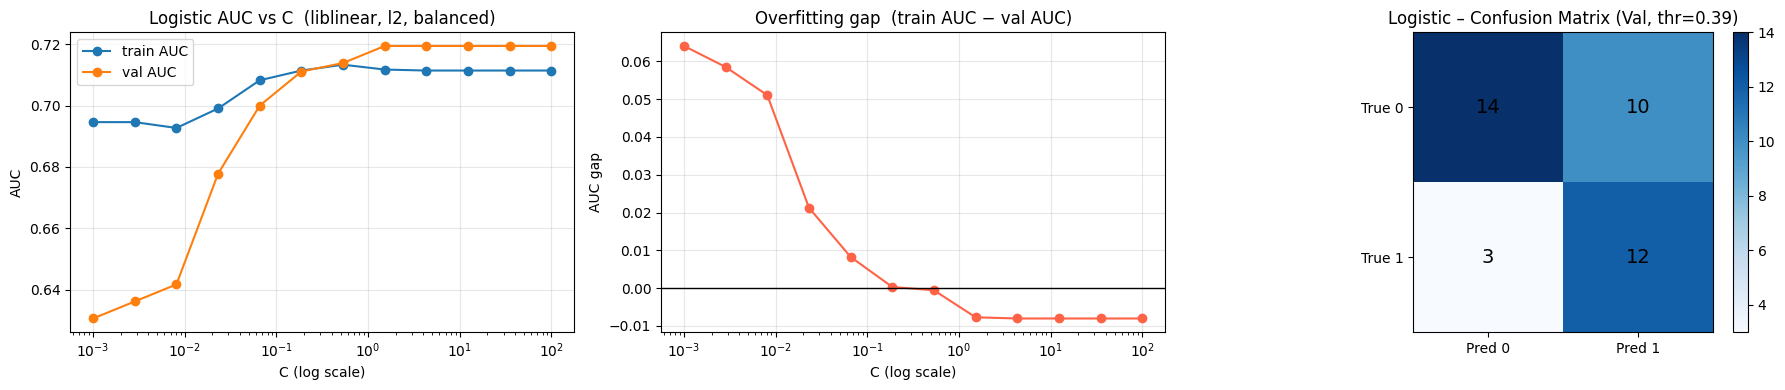

In [56]:
# ══════════════════════════════════════════════
# PART A) Logistic Regression – hyperparameter search
# ══════════════════════════════════════════════

log_grid = {
    "penalty"     : ["l1", "l2"],
    "C"           : np.logspace(-3, 2, 12),
    "solver"      : ["liblinear"],          # liblinear supports l1 & l2
    "class_weight": ["balanced"],
}

log_results = []
for cfg in ParameterGrid(log_grid):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=42, **cfg)),
    ])
    pipe.fit(X_train, y_train)
    p_tr = pipe.predict_proba(X_train)[:, 1]
    p_va = pipe.predict_proba(X_val)[:, 1]
    m_tr = metrics_from_prob(y_train, p_tr)
    m_va = metrics_from_prob(y_val,   p_va)
    log_results.append({
        **cfg,
        "train_auc": m_tr["auc"], "val_auc": m_va["auc"],
        "train_f1" : m_tr["f1"],  "val_f1" : m_va["f1"],
        "train_acc": m_tr["acc"], "val_acc": m_va["acc"],
        "gap_auc"  : m_tr["auc"] - m_va["auc"],
    })

# ── Sort by val_auc (AUC is more informative than accuracy on imbalanced data)
log_df = pd.DataFrame(log_results).sort_values(
    by=["val_auc", "val_f1"], ascending=False
).reset_index(drop=True)

print("\n=== Logistic top configs (sorted by val AUC) ===")
print(log_df.head(10).to_string())

# ── Best config & retrain
best_log_row = log_df.iloc[0]
best_log_cfg = best_log_row[["penalty", "C", "solver", "class_weight"]].to_dict()
print("\nBest logistic config:", best_log_cfg)

best_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42, **best_log_cfg)),
])
best_log.fit(X_train, y_train)
p_train_log = best_log.predict_proba(X_train)[:, 1]
p_val_log   = best_log.predict_proba(X_val)[:, 1]

# ── Optimal threshold (maximises val F1)
thr_log = best_threshold(y_val, p_val_log)
print(f"Optimal threshold (log): {thr_log:.2f}")

m_train_log = metrics_from_prob(y_train, p_train_log, thr=thr_log)
m_val_log   = metrics_from_prob(y_val,   p_val_log,   thr=thr_log)
print("Train:", m_train_log)
print("Val  :", m_val_log)

# ── Logistic plots
best_pen = best_log_row["penalty"]
curve_df = log_df[
    (log_df["solver"] == "liblinear") &
    (log_df["penalty"] == best_pen) &
    (log_df["class_weight"] == "balanced")
].sort_values("C")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].plot(curve_df["C"], curve_df["train_auc"], marker="o", label="train AUC")
ax[0].plot(curve_df["C"], curve_df["val_auc"],   marker="o", label="val AUC")
ax[0].set_xscale("log")
ax[0].set_title(f"Logistic AUC vs C  (liblinear, {best_pen}, balanced)")
ax[0].set_xlabel("C (log scale)"); ax[0].set_ylabel("AUC")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(curve_df["C"], curve_df["gap_auc"], marker="o", color="tomato")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_xscale("log")
ax[1].set_title("Overfitting gap  (train AUC − val AUC)")
ax[1].set_xlabel("C (log scale)"); ax[1].set_ylabel("AUC gap")
ax[1].grid(alpha=0.3)

cm_log = confusion_matrix(y_val, (p_val_log >= thr_log).astype(int))
im = ax[2].imshow(cm_log, cmap="Blues")
ax[2].set_title(f"Logistic – Confusion Matrix (Val, thr={thr_log:.2f})")
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["Pred 0", "Pred 1"])
ax[2].set_yticks([0, 1]); ax[2].set_yticklabels(["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, cm_log[i, j], ha="center", va="center", fontsize=14)
plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


=== MLP top configs (sorted by val AUC) ===
  activation    alpha  batch_size  beta_1  beta_2 hidden_layer_sizes  learning_rate_init solver  train_auc   val_auc  train_f1    val_f1   gap_auc  train_logloss  val_logloss  n_iter learning_rate  momentum nesterovs_momentum
0       tanh  0.00010          32    0.80   0.999           (64, 32)              0.0005   adam   0.729524  0.747222  0.468750  0.222222 -0.017698       0.584542     0.604583      92           NaN       NaN                NaN
1       tanh  0.00001          32    0.95   0.999           (64, 32)              0.0005   adam   0.709841  0.725000  0.444444  0.222222 -0.015159       0.595243     0.611494      65           NaN       NaN                NaN
2       tanh  0.00010          32    0.95   0.990              (16,)              0.0005   adam   0.695873  0.688889  0.609524  0.571429  0.006984       0.666457     0.652948     113           NaN       NaN                NaN
3       tanh  0.00100          16     NaN     NaN  

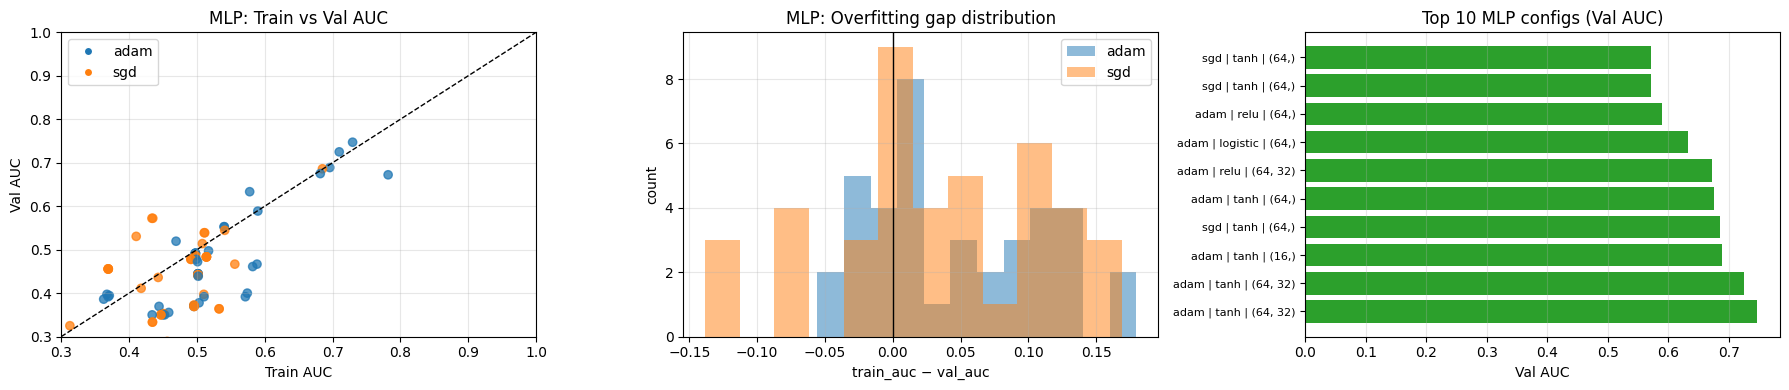

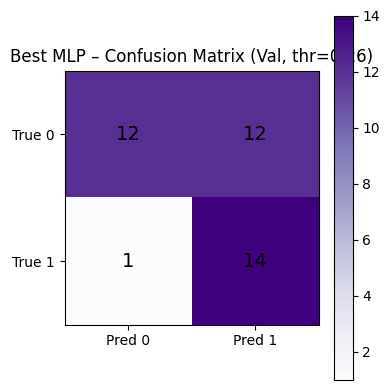

In [57]:
# ══════════════════════════════════════════════
# PART B) MLP – hyperparameter search (Adam + SGD/momentum)
# ══════════════════════════════════════════════

mlp_space_adam = {
    "solver"            : ["adam"],
    "activation"        : ["relu", "tanh", "logistic"],
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)],
    "alpha"             : [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
    "beta_1"            : [0.8, 0.9, 0.95],
    "beta_2"            : [0.99, 0.999],
    "batch_size"        : [16, 32],
}

mlp_space_sgd = {
    "solver"            : ["sgd"],
    "activation"        : ["relu", "tanh"],
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32)],
    "alpha"             : [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
    "learning_rate"     : ["constant", "adaptive"],
    "momentum"          : [0.0, 0.5, 0.9],
    "nesterovs_momentum": [False, True],
    "batch_size"        : [16, 32],
}

all_cfgs = list(ParameterGrid(mlp_space_adam)) + list(ParameterGrid(mlp_space_sgd))
np.random.shuffle(all_cfgs)

N_TRIALS = 80
cfgs = all_cfgs[:N_TRIALS]

mlp_results = []
for i, cfg in enumerate(cfgs, 1):
    try:
        clf = MLPClassifier(
            random_state=42, max_iter=700,
            early_stopping=True, validation_fraction=0.2,
            n_iter_no_change=25, **cfg,
        )
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        pipe.fit(X_train, y_train)

        p_tr = pipe.predict_proba(X_train)[:, 1]
        p_va = pipe.predict_proba(X_val)[:, 1]
        m_tr = metrics_from_prob(y_train, p_tr)
        m_va = metrics_from_prob(y_val,   p_va)

        mlp_results.append({
            **cfg,
            "train_auc"  : m_tr["auc"],   "val_auc"  : m_va["auc"],
            "train_f1"   : m_tr["f1"],    "val_f1"   : m_va["f1"],
            "gap_auc"    : m_tr["auc"] - m_va["auc"],
            "train_logloss": m_tr["logloss"],
            "val_logloss"  : m_va["logloss"],
            "n_iter"     : pipe.named_steps["clf"].n_iter_,
        })
    except Exception:
        continue

mlp_df = pd.DataFrame(mlp_results).sort_values(
    by=["val_auc", "val_f1"], ascending=False
).reset_index(drop=True)

print("\n=== MLP top configs (sorted by val AUC) ===")
print(mlp_df.head(10).to_string())
print("\nConfigs avaluades:", len(mlp_df), "/", N_TRIALS)

# ── Best MLP config & retrain
best_mlp_row = mlp_df.iloc[0]
best_mlp_cfg = best_mlp_row[[
    "solver", "activation", "hidden_layer_sizes", "alpha",
    "learning_rate_init", "batch_size",
]].to_dict()

if best_mlp_cfg["solver"] == "adam":
    best_mlp_cfg["beta_1"] = best_mlp_row["beta_1"]
    best_mlp_cfg["beta_2"] = best_mlp_row["beta_2"]
else:
    best_mlp_cfg["learning_rate"]       = best_mlp_row["learning_rate"]
    best_mlp_cfg["momentum"]            = best_mlp_row["momentum"]
    best_mlp_cfg["nesterovs_momentum"]  = best_mlp_row["nesterovs_momentum"]

print("\nBest MLP config:", best_mlp_cfg)

best_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        random_state=42, max_iter=900,
        early_stopping=True, validation_fraction=0.2,
        n_iter_no_change=30, **best_mlp_cfg,
    )),
])
best_mlp.fit(X_train, y_train)

p_train_mlp = best_mlp.predict_proba(X_train)[:, 1]
p_val_mlp   = best_mlp.predict_proba(X_val)[:, 1]

# ── Optimal threshold (maximises val F1)
thr_mlp = best_threshold(y_val, p_val_mlp)
print(f"Optimal threshold (MLP): {thr_mlp:.2f}")

m_train_mlp = metrics_from_prob(y_train, p_train_mlp, thr=thr_mlp)
m_val_mlp   = metrics_from_prob(y_val,   p_val_mlp,   thr=thr_mlp)
print("Train:", m_train_mlp)
print("Val  :", m_val_mlp)

# ── MLP plots
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

colors = mlp_df["solver"].map({"adam": "tab:blue", "sgd": "tab:orange"}).values
ax[0].scatter(mlp_df["train_auc"], mlp_df["val_auc"], c=colors, alpha=0.75)
ax[0].plot([0.3, 1.0], [0.3, 1.0], "k--", linewidth=1)
ax[0].set_xlim(0.3, 1.0); ax[0].set_ylim(0.3, 1.0)
ax[0].set_xlabel("Train AUC"); ax[0].set_ylabel("Val AUC")
ax[0].set_title("MLP: Train vs Val AUC")
ax[0].grid(alpha=0.3)
# Manual legend for solver colours
from matplotlib.lines import Line2D
ax[0].legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="tab:blue",  label="adam"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="tab:orange", label="sgd"),
], loc="upper left")

for solver, color in [("adam", "tab:blue"), ("sgd", "tab:orange")]:
    vals = mlp_df.loc[mlp_df["solver"] == solver, "gap_auc"].values
    if len(vals):
        ax[1].hist(vals, bins=12, alpha=0.5, label=solver, color=color)
ax[1].axvline(0, color="black", linewidth=1)
ax[1].set_title("MLP: Overfitting gap distribution")
ax[1].set_xlabel("train_auc − val_auc"); ax[1].set_ylabel("count")
ax[1].legend(); ax[1].grid(alpha=0.3)

top10   = mlp_df.head(10).copy()
labels  = [f"{r['solver']} | {r['activation']} | {r['hidden_layer_sizes']}"
           for _, r in top10.iterrows()]
ax[2].barh(range(len(top10))[::-1], top10["val_auc"].values[::-1], color="tab:green")
ax[2].set_yticks(range(len(top10))[::-1])
ax[2].set_yticklabels(labels[::-1], fontsize=8)
ax[2].set_title("Top 10 MLP configs (Val AUC)")
ax[2].set_xlabel("Val AUC"); ax[2].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# ── Confusion matrix best MLP
cm_mlp = confusion_matrix(y_val, (p_val_mlp >= thr_mlp).astype(int))
plt.figure(figsize=(4, 4))
plt.imshow(cm_mlp, cmap="Purples")
plt.title(f"Best MLP – Confusion Matrix (Val, thr={thr_mlp:.2f})")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_mlp[i, j], ha="center", va="center", fontsize=14)
plt.colorbar(); plt.tight_layout(); plt.show()


=== Final summary (metrics at optimal threshold) ===
   model split      auc       f1      acc  precision   recall  logloss
Logistic train 0.711746 0.564103 0.564103   0.440000 0.785714 0.625562
Logistic   val 0.719444 0.648649 0.666667   0.545455 0.800000 0.613733
     MLP train 0.729524 0.580645 0.555556   0.439024 0.857143 0.584542
     MLP   val 0.747222 0.682927 0.666667   0.538462 0.933333 0.604583


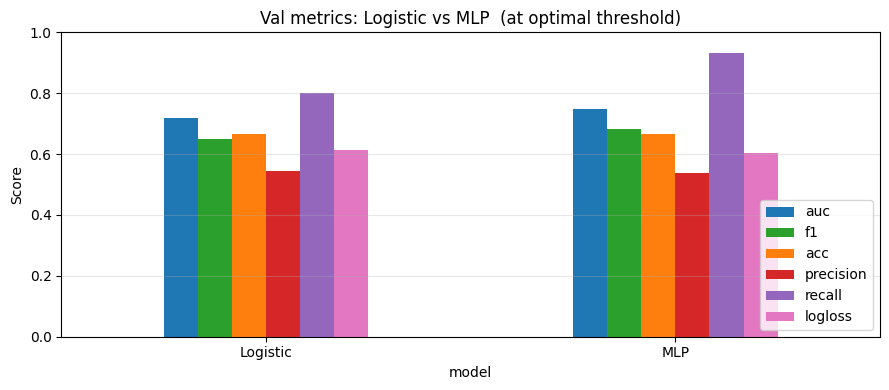


>>> Recommended model: MLP  (val AUC = 0.7472)


In [61]:
# ══════════════════════════════════════════════
# PART C) Final comparison & model selection
# ══════════════════════════════════════════════

summary = pd.DataFrame([
    {"model": "Logistic", "split": "train", **m_train_log},
    {"model": "Logistic", "split": "val",   **m_val_log},
    {"model": "MLP",      "split": "train", **m_train_mlp},
    {"model": "MLP",      "split": "val",   **m_val_mlp},
])
cols = ["model", "split", "auc", "f1", "acc", "precision", "recall", "logloss"]
print("\n=== Final summary (metrics at optimal threshold) ===")
print(summary[cols].to_string(index=False))

# ── Bar chart: val metrics comparison
val_summary = summary[summary["split"] == "val"].set_index("model")
metric_cols  = ["auc", "f1", "acc", "precision", "recall", "logloss"]
val_summary[metric_cols].plot(kind="bar", figsize=(9, 4), rot=0,
                               color=["tab:blue","tab:green","tab:orange","tab:red","tab:purple","tab:pink"])
plt.title("Val metrics: Logistic vs MLP  (at optimal threshold)")
plt.ylabel("Score"); plt.ylim(0, 1)
plt.legend(loc="lower right"); plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# ── Pick final model
best_model_name = val_summary["auc"].idxmax()
print(f"\n>>> Recommended model: {best_model_name}  "
      f"(val AUC = {val_summary.loc[best_model_name, 'auc']:.4f})")

AUC és el més adequat per a la cerca i selecció de models, i aquí tens el raonament:

Per què NO accuracy sola:
El dataset té ~36% positius (no és extremadament desbalancejat, però tampoc trivial). Un model que prediu sempre 0 tindria ~64% accuracy sense aprendre res. L'accuracy amaga si el model detecta els positius o no.
Per què F1 és útil però limitat per a la cerca:
F1 depèn del threshold (0.5 per defecte). Durant el grid search estàs comparant models amb probabilitats de sortida molt diverses, i usar F1 a threshold fix penalitza injustament models que necessiten un threshold diferent. A més, F1 ignora els true negatives.
Per què AUC és el millor per a la cerca:

És independent del threshold → compara models de forma justa
Mesura la capacitat discriminativa pura del model
Robust a desequilibri de classes moderat


El flux lògic correcte és:
Grid search → ordenar per val_AUC (troba el millor model)
         ↓
Threshold òptim → maximitzar F1 al val (ajusta la decisió)
         ↓
Informe final → mostrar AUC + F1 + recall (mètriques completes)
En un problema mèdic com aquest (detectar desorientació), el recall és especialment important al final: un fals negatiu (no detectar un pacient en risc) és molt pitjor que un fals positiu. Per tant el threshold òptim hauria de prioritzar recall alt, no F1 màxim.